# ExplainPhish: HTML Phishing Detection - Data Overview & Feature Analysis
This notebook provides an in-depth **Data Overview** and exploratory data analysis for the **HTML** modality of the **ExplainPhish** project.

The dataset is derived from the **CIC-Trap4Phish2025** benchmark, consisting of static features extracted from legitimate (benign) and phishing HTML documents. No active macros, scripts, or network requests are executed during this analysis; detection relies entirely on safe, static structural, lexical, and script characteristics.

---

## Contents
- [1. Setup & Environment](#scrollTo=setup)
  - [1.1 Import Libraries](#scrollTo=import_libraries)
  - [1.2 Adaptive Path Resolution](#scrollTo=path_config)
- [2. Loading the Data & Data Overview](#scrollTo=loading_data)
  - [2.1 Raw Loading](#scrollTo=raw_loading)
  - [2.2 Data Cleaning & Artifact Removal](#scrollTo=data_cleaning)
  - [2.3 Feature Inventory & Data Types](#scrollTo=feature_inventory)
  - [2.4 Summary & Descriptive Statistics](#scrollTo=descriptive_stats)
  - [2.5 Target Class Balance Analysis](#scrollTo=class_balance)
  - [2.6 HTML Feature Definitions & Threat Relevance](#scrollTo=feature_definitions)
- [3. Visualizing and Understanding the Data](#scrollTo=sec3)
  - [3.1 Checking Missing Values](#scrollTo=sec3_1)
  - [3.2 Visualization and Analysis of Each Feature (Distribution Evenness)](#scrollTo=sec3_2)
    - [3.2.1 Skewness & Distribution Evenness Assessment](#scrollTo=sec3_2_1)
    - [3.2.2 Full Feature Distribution Overview (Grid Visualization)](#scrollTo=sec3_2_2)
    - [3.2.3 TARGET Column (Class Evenness)](#scrollTo=sec3_2_3)
    - [3.2.4 Evenly Distributed Attributes (Entropy & Whitespace Ratios)](#scrollTo=sec3_2_4)
    - [3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation](#scrollTo=sec3_2_5)
    - [3.2.6 URL & Navigation Link Attributes](#scrollTo=sec3_2_6)
    - [3.2.7 Comprehensive Evenness & Distribution Summary Table](#scrollTo=sec3_2_7)
  - [3.3 Summary Findings & Next Steps](#scrollTo=sec3_3)
- [4. Dataset Preparation](#scrollTo=dataset_prep)
  - [4.1 Feature Matrix (X) and Target Vector (y)](#scrollTo=xy_split)
  - [4.2 Stratified 60/40 Train/Test Split](#scrollTo=train_test_split)

<a name="setup"></a>
## 1. Setup & Environment

In this section, we set up the environment, import standard data science and visualization libraries with consistent visual themes, and locate the dataset file.

<a name="import_libraries"></a>
### 1.1 Import Libraries
We import `pandas` for tabular data manipulation, `numpy` for numerical calculations, `matplotlib` and `seaborn` for visualizations, and `pathlib` for flexible cross-platform path resolution.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

print("Environment configured successfully with consistent visual theme!")

Environment configured successfully with consistent visual theme!


<a name="path_config"></a>
### 1.2 Adaptive Path Resolution
To ensure this notebook runs seamlessly whether executed locally in VS Code / Jupyter, from the repository root, or in Google Colab (with or without Google Drive mounted), we define adaptive path resolution for `HTML_Top13_Features.csv`.

In [2]:
# Adaptive path detection for local environments and Google Colab
candidates = [
    Path("data/html/HTML_Top13_Features.csv"),
    Path("googleCollab/data/html/HTML_Top13_Features.csv"),
    Path("../data/html/HTML_Top13_Features.csv"),
    Path("../googleCollab/data/html/HTML_Top13_Features.csv"),
    Path("../../googleCollab/data/html/HTML_Top13_Features.csv"),
    Path("/content/drive/MyDrive/ExplainPhish/data/html/HTML_Top13_Features.csv"),
    Path("/content/drive/MyDrive/ExplainPhish/googleCollab/data/html/HTML_Top13_Features.csv"),
    Path("/content/HTML_Top13_Features.csv")
]

dataset_path = None
for p in candidates:
    if p.exists():
        dataset_path = p
        break

if dataset_path is not None:
    print(f"Dataset located successfully at:\n{dataset_path.resolve()}")
else:
    raise FileNotFoundError(
        "Could not automatically locate 'HTML_Top13_Features.csv'. "
        "Please upload the file to Google Colab or verify the directory path."
    )

Dataset located successfully at:
D:\codingProject\ExplainPhish\googleCollab\data\html\HTML_Top13_Features.csv


<a name="loading_data"></a>
## 2. Loading the Data & Data Overview

In this section, we load the raw HTML feature table, sanitize export artifacts, examine dataset dimensions, inspect column types, evaluate summary statistics, evaluate class balance, and review the security relevance of each feature.

<a name="raw_loading"></a>
### 2.1 Raw Loading
We load the raw CSV file into a `pandas.DataFrame` and preview the first 5 records.

In [3]:
# Load raw dataset
raw_df = pd.read_csv(dataset_path)

print(f"Raw Dataset Dimensions: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
raw_df.head(5)

Raw Dataset Dimensions: 19,997 rows x 27 columns


,file_name,url_punct_char_count,tag_count,whitespace_ratio,entropy,form_count,embedded_js_count,html_whitespace_ratio,script_entropy,min_link_length,external_link_count,total_script_characters,internal_link_count,url_digit_count,label,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
0,sample_09001.html,756,475,0.4769,5.0729,0,11,0.1527,4.9064,1,57,15762,39,109,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sample_09002.html,287,82,0.3566,5.2020,0,3,0.1795,4.6251,21,8,2543,27,130,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sample_09003.html,667,406,0.3902,5.1642,1,10,0.1498,4.2204,9,80,7163,26,333,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sample_09004.html,1204,321,0.5348,5.6712,0,33,0.0257,5.6267,17,74,268250,2,1013,0,NaN,NaN,NaN,9998.0000,NaN,NaN,NaN,NaN,9998.0000,NaN,NaN,NaN
4,sample_09005.html,2606,665,0.4416,5.1366,5,8,0.1301,5.4630,8,243,7666,8,924,0,NaN,NaN,NaN,10000.0000,NaN,19998.0000,9999.0000,NaN,10000.0000,NaN,19998.0000,11998.8000


<a name="data_cleaning"></a>
### 2.2 Data Cleaning & Artifact Removal
Notice that the raw CSV file contains trailing `Unnamed: 15` through `Unnamed: 26` columns. These are empty artifacts caused by trailing delimiters during export. We identify and drop these empty columns, reducing the table to the sample identifier (`file_name`), 13 security features, and target label (`label`).

In [4]:
# Identify trailing artifact columns
unnamed_cols = [c for c in raw_df.columns if "unnamed" in c.lower()]
print(f"Identified {len(unnamed_cols)} trailing artifact columns to drop: {unnamed_cols}")

# Drop artifact columns to produce clean dataframe
df = raw_df.drop(columns=unnamed_cols).copy()

print(f"Cleaned Dataset Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(5)

Identified 12 trailing artifact columns to drop: ['Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26']
Cleaned Dataset Dimensions: 19,997 rows x 15 columns


,file_name,url_punct_char_count,tag_count,whitespace_ratio,entropy,form_count,embedded_js_count,html_whitespace_ratio,script_entropy,min_link_length,external_link_count,total_script_characters,internal_link_count,url_digit_count,label
0,sample_09001.html,756,475,0.4769,5.0729,0,11,0.1527,4.9064,1,57,15762,39,109,0
1,sample_09002.html,287,82,0.3566,5.2020,0,3,0.1795,4.6251,21,8,2543,27,130,0
2,sample_09003.html,667,406,0.3902,5.1642,1,10,0.1498,4.2204,9,80,7163,26,333,0
3,sample_09004.html,1204,321,0.5348,5.6712,0,33,0.0257,5.6267,17,74,268250,2,1013,0
4,sample_09005.html,2606,665,0.4416,5.1366,5,8,0.1301,5.4630,8,243,7666,8,924,0


<a name="feature_inventory"></a>
### 2.3 Feature Inventory & Data Types
Let's inspect the data types, non-null counts, and memory footprint of the cleaned dataset.

In [5]:
# Inspect column data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19997 entries, 0 to 19996
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   file_name                19997 non-null  str    
 1   url_punct_char_count     19997 non-null  int64  
 2   tag_count                19997 non-null  int64  
 3   whitespace_ratio         19997 non-null  float64
 4   entropy                  19997 non-null  float64
 5   form_count               19997 non-null  int64  
 6   embedded_js_count        19997 non-null  int64  
 7   html_whitespace_ratio    19997 non-null  float64
 8   script_entropy           19997 non-null  float64
 9   min_link_length          19997 non-null  int64  
 10  external_link_count      19997 non-null  int64  
 11  total_script_characters  19997 non-null  int64  
 12  internal_link_count      19997 non-null  int64  
 13  url_digit_count          19997 non-null  int64  
 14  label                    19997 no

<a name="descriptive_stats"></a>
### 2.4 Summary & Descriptive Statistics
Let's analyze the statistical distribution (mean, standard deviation, min, 25th percentile, median, 75th percentile, and max) for all 13 numeric HTML features.

In [6]:
# Extract numeric feature columns (excluding file identifier and target label)
feature_cols = [c for c in df.columns if c not in ["file_name", "label"]]

# Compute descriptive statistics
stats_df = df[feature_cols].describe().T
stats_df["median"] = df[feature_cols].median()
stats_df = stats_df[["count", "mean", "std", "min", "25%", "median", "75%", "max"]]

stats_df

,count,mean,std,min,25%,median,75%,max
url_punct_char_count,19997.0000,884.2841,3466.0368,0.0000,47.0000,265.0000,1037.0000,283826.0000
tag_count,19997.0000,483.9136,984.3284,3.0000,57.0000,182.0000,600.0000,43591.0000
whitespace_ratio,19997.0000,0.3716,0.1644,0.0000,0.2863,0.3960,0.4873,0.8544
entropy,19997.0000,5.1664,0.3877,0.9144,4.9917,5.1790,5.3541,7.8747
form_count,19997.0000,1.3196,2.8331,0.0000,0.0000,1.0000,2.0000,189.0000
embedded_js_count,19997.0000,7.2617,12.3293,0.0000,1.0000,3.0000,9.0000,333.0000
html_whitespace_ratio,19997.0000,0.1183,0.0762,0.0000,0.0706,0.1082,0.1492,0.8301
script_entropy,19997.0000,4.1169,2.0508,0.0000,4.3563,5.0423,5.3660,6.2742
min_link_length,19997.0000,20.7234,686.9872,0.0000,1.0000,1.0000,11.0000,77698.0000
external_link_count,19997.0000,55.1496,119.7534,0.0000,1.0000,16.0000,66.0000,5550.0000


<a name="class_balance"></a>
### 2.5 Target Class Balance Analysis
In cybersecurity and phishing classification, heavily skewed datasets (class imbalance) can lead to models that deceptively show high accuracy while missing threats. Let's analyze the distribution of our target variable `label`:
- **0**: Benign / Legitimate HTML file
- **1**: Phishing / Malicious HTML file

,Class,Sample Count,Proportion (%)
0,Phishing (1),9999,50.0025
1,Benign (0),9998,49.9975


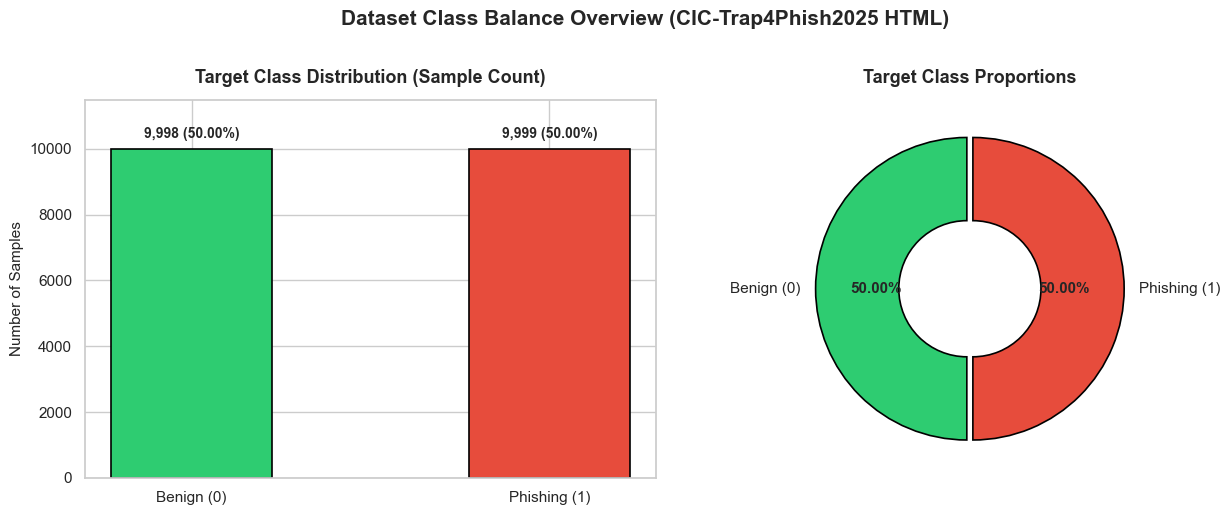

In [7]:
# Target class counts and percentages
counts = df["label"].value_counts()
proportions = df["label"].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    "Class": ["Phishing (1)", "Benign (0)"] if counts.index[0] == 1 else ["Benign (0)", "Phishing (1)"],
    "Sample Count": [counts[1], counts[0]],
    "Proportion (%)": [proportions[1], proportions[0]]
})

display(class_summary)

# Side-by-side visualization: Count bar chart and proportion donut chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. Bar chart
colors = ["#2ecc71", "#e74c3c"]
bars = ax1.bar(
    ["Benign (0)", "Phishing (1)"], 
    [counts[0], counts[1]], 
    color=colors, 
    width=0.45, 
    edgecolor="black", 
    linewidth=1.2
)
ax1.set_title("Target Class Distribution (Sample Count)", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Number of Samples", fontsize=11)
ax1.set_ylim(0, max(counts) * 1.15)
for bar in bars:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2, 
        yval + 250, 
        f"{int(yval):,} ({yval / len(df) * 100:.2f}%)", 
        ha="center", 
        va="bottom", 
        fontweight="bold", 
        fontsize=10
    )

# 2. Donut / Pie chart
wedges, texts, autotexts = ax2.pie(
    [counts[0], counts[1]],
    labels=["Benign (0)", "Phishing (1)"],
    autopct="%1.2f%%",
    startangle=90,
    colors=colors,
    explode=(0.02, 0.02),
    wedgeprops=dict(width=0.55, edgecolor="black", linewidth=1.2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
ax2.set_title("Target Class Proportions", fontsize=13, fontweight="bold", pad=12)

plt.suptitle("Dataset Class Balance Overview (CIC-Trap4Phish2025 HTML)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

<a name="feature_definitions"></a>
### 2.6 HTML Feature Definitions & Threat Relevance

The 13 extracted features capture structural, lexical, script, and URL characteristics designed to separate phishing artifacts from benign web content without requiring code execution:

| # | Feature Name | Data Type | Description & Security Relevance |
| :--- | :--- | :--- | :--- |
| 1 | `url_punct_char_count` | Integer | Total punctuation characters (`/`, `.`, `-`, `_`, `=`, `?`, `&`, `;`) across all extracted URLs. Phishing links often employ nested redirects, base64 query tokens, or deceptive subdomains with heavy punctuation. |
| 2 | `tag_count` | Integer | Total count of HTML tags in the DOM. Legitimate portals have rich DOM structures (median ~514 tags), whereas phishing templates tend to be minimal landing pages (median ~91 tags) focused only on the credential trap. |
| 3 | `whitespace_ratio` | Float | Ratio of whitespace in extracted text. Phishers often introduce abnormal whitespace padding or zero-width spaces to bypass simple keyword filters. |
| 4 | `entropy` | Float | Shannon entropy of the overall raw HTML document. Measures informational randomness; obfuscated, packed, or encoded HTML shows distinctive entropy signatures. |
| 5 | `form_count` | Integer | Total `<form>` elements. Phishing attacks almost universally revolve around harvesting credentials (usernames, passwords, MFA codes, credit cards) through web forms. |
| 6 | `embedded_js_count` | Integer | Number of inline `<script>` blocks (scripts without an external `src`). Inline scripts are commonly used in phishing kits to perform browser fingerprinting or credential exfiltration without external domain lookups. |
| 7 | `html_whitespace_ratio` | Float | Ratio of whitespace across the full HTML source code. Reflects formatting, code minification, or packing patterns. |
| 8 | `script_entropy` | Float | Shannon entropy calculated specifically over JavaScript code blocks. Packed, obfuscated, or encrypted JavaScript payloads produce noticeably higher entropy. |
| 9 | `min_link_length` | Integer | Character length of the shortest hyperlink in the page. Decoy templates or broken phishing clones frequently contain single-character links (`#`, `/`). |
| 10 | `external_link_count` | Integer | Number of hyperlinks referencing external domains. Legitimate sites have diverse internal/external navigation, while phishing kits restrict external outbound links to keep the victim focused on the capture form. |
| 11 | `total_script_characters`| Integer | Cumulative character count of all JavaScript blocks. Distinguishes rich modern web applications from compact phishing capture scripts. |
| 12 | `internal_link_count` | Integer | Number of relative or same-domain hyperlinks. Legitimate sites feature extensive site navigation (median ~32 links), while phishing sites rarely implement functional internal links (median ~6 links). |
| 13 | `url_digit_count` | Integer | Total numeric digits across all hyperlinks. Phishing URLs frequently incorporate numeric IP addresses, hexadecimal identifiers, or randomized session tokens. |

<a name="sec3"></a>
## 3. Visualizing and Understanding the Data

The first thing we need to do before building the machine learning model is to **understand the data**. We do this by visualizing and analyzing, to deepen our understanding of data distribution, missing values, outliers, correlations, and etc. The results of the analysis obtained at this stage will be useful for preprocessing, feature creation, and selection of machine learning models, which are all important to building models with better prediction ability.

<a name="sec3_1"></a>
### 3.1 Checking Missing Values
In this section, we check for missing values.
This is important as **most machine learning models cannot be trained on data with missing values**. If there are missing values, they need to be filled with some value or handled during preprocessing.

In [8]:
# Check missing values of all columns
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_pct
})

missing_cols = missing_df[missing_df["Missing Values"] > 0]
if len(missing_cols) == 0:
    print(f"No missing values found across all {df.shape[1]} columns! Dataset is 100% complete.")
else:
    print(f"Found {len(missing_cols)} columns with missing values:")
    display(missing_cols)

No missing values found across all 15 columns! Dataset is 100% complete.


**Findings**:<br>
* The dataset is **100% complete with 0 missing values** across all 13 features and target. No imputation or removal is required.

<a name="sec3_2"></a>
### 3.2 Visualization and Analysis of Each Feature

In this section, we visualize each feature and analyze to see what kind of characteristics it has.

Specifically, we **check whether the feature is evenly distributed for each attribute**, assess skewness and outliers, evaluate zero-inflation, and contrast how each feature is distributed between legitimate and phishing web files.

<a name="sec3_2_1"></a>
#### 3.2.1 Skewness & Distribution Evenness Assessment

A feature is considered **evenly distributed (symmetric)** if its values are balanced around the mean and median with a skewness coefficient near 0 ($|\text{skew}| < 0.5$). 
- Skewness between $-0.5$ and $+0.5$ indicates an **evenly distributed / symmetric** attribute (often Gaussian / bell-shaped).
- Skewness between $0.5$ and $1.5$ (or $-0.5$ and $-1.5$) indicates a **moderately skewed** attribute.
- Skewness $> 1.5$ indicates a **highly skewed / heavy-tailed** attribute (following a power-law, log-normal, or zero-inflated distribution).

Let's compute the distribution evenness metrics for each of the 13 attributes:

In [9]:
# Assess distribution evenness and skewness for each feature
evenness_records = []
for col in feature_cols:
    sk = df[col].skew()
    zero_ratio = (df[col] == 0).mean() * 100
    mean_val = df[col].mean()
    median_val = df[col].median()
    std_val = df[col].std()
    min_val = df[col].min()
    max_val = df[col].max()
    
    if abs(sk) < 0.5:
        evenness = "Evenly Distributed (Symmetric)"
        profile = "Bell-shaped / Gaussian-like"
    elif abs(sk) < 1.5:
        evenness = "Moderately Skewed"
        profile = "Slight Right/Left Tilt"
    else:
        evenness = f"Highly Right-Skewed (skew={sk:.1f})"
        profile = "Heavy-Tailed / Power-Law"
    
    evenness_records.append({
        "Feature Name": col,
        "Skewness": round(sk, 2),
        "Zero %": round(zero_ratio, 1),
        "Min": round(min_val, 2),
        "Mean": round(mean_val, 2),
        "Median": round(median_val, 2),
        "Max": round(max_val, 2),
        "Evenness Assessment": evenness,
        "Distribution Profile": profile
    })

evenness_table = pd.DataFrame(evenness_records).sort_values(by="Skewness", key=abs)
display(evenness_table.reset_index(drop=True))

,Feature Name,Skewness,Zero %,Min,Mean,Median,Max,Evenness Assessment,Distribution Profile
0,entropy,-0.4100,0.0000,0.9100,5.1700,5.1800,7.8700,Evenly Distributed (Symmetric),Bell-shaped / Gaussian-like
1,whitespace_ratio,-0.5800,5.7000,0.0000,0.3700,0.4000,0.8500,Moderately Skewed,Slight Right/Left Tilt
2,script_entropy,-1.4100,19.2000,0.0000,4.1200,5.0400,6.2700,Moderately Skewed,Slight Right/Left Tilt
3,html_whitespace_ratio,1.5800,0.0000,0.0000,0.1200,0.1100,0.8300,Highly Right-Skewed (skew=1.6),Heavy-Tailed / Power-Law
4,embedded_js_count,5.7700,19.0000,0.0000,7.2600,3.0000,333.0000,Highly Right-Skewed (skew=5.8),Heavy-Tailed / Power-Law
5,total_script_characters,10.3900,13.3000,0.0000,23134.8500,2774.0000,2506028.0000,Highly Right-Skewed (skew=10.4),Heavy-Tailed / Power-Law
6,tag_count,12.1100,0.0000,3.0000,483.9100,182.0000,43591.0000,Highly Right-Skewed (skew=12.1),Heavy-Tailed / Power-Law
7,internal_link_count,13.0700,13.4000,0.0000,55.6300,11.0000,6190.0000,Highly Right-Skewed (skew=13.1),Heavy-Tailed / Power-Law
8,external_link_count,13.4400,19.2000,0.0000,55.1500,16.0000,5550.0000,Highly Right-Skewed (skew=13.4),Heavy-Tailed / Power-Law
9,form_count,28.0200,31.4000,0.0000,1.3200,1.0000,189.0000,Highly Right-Skewed (skew=28.0),Heavy-Tailed / Power-Law


<a name="sec3_2_2"></a>
#### 3.2.2 Full Feature Distribution Overview (Grid Visualization)

Let's plot the raw distribution (histogram with KDE curve) for all 13 features to visualize which attributes are evenly distributed versus heavily skewed:

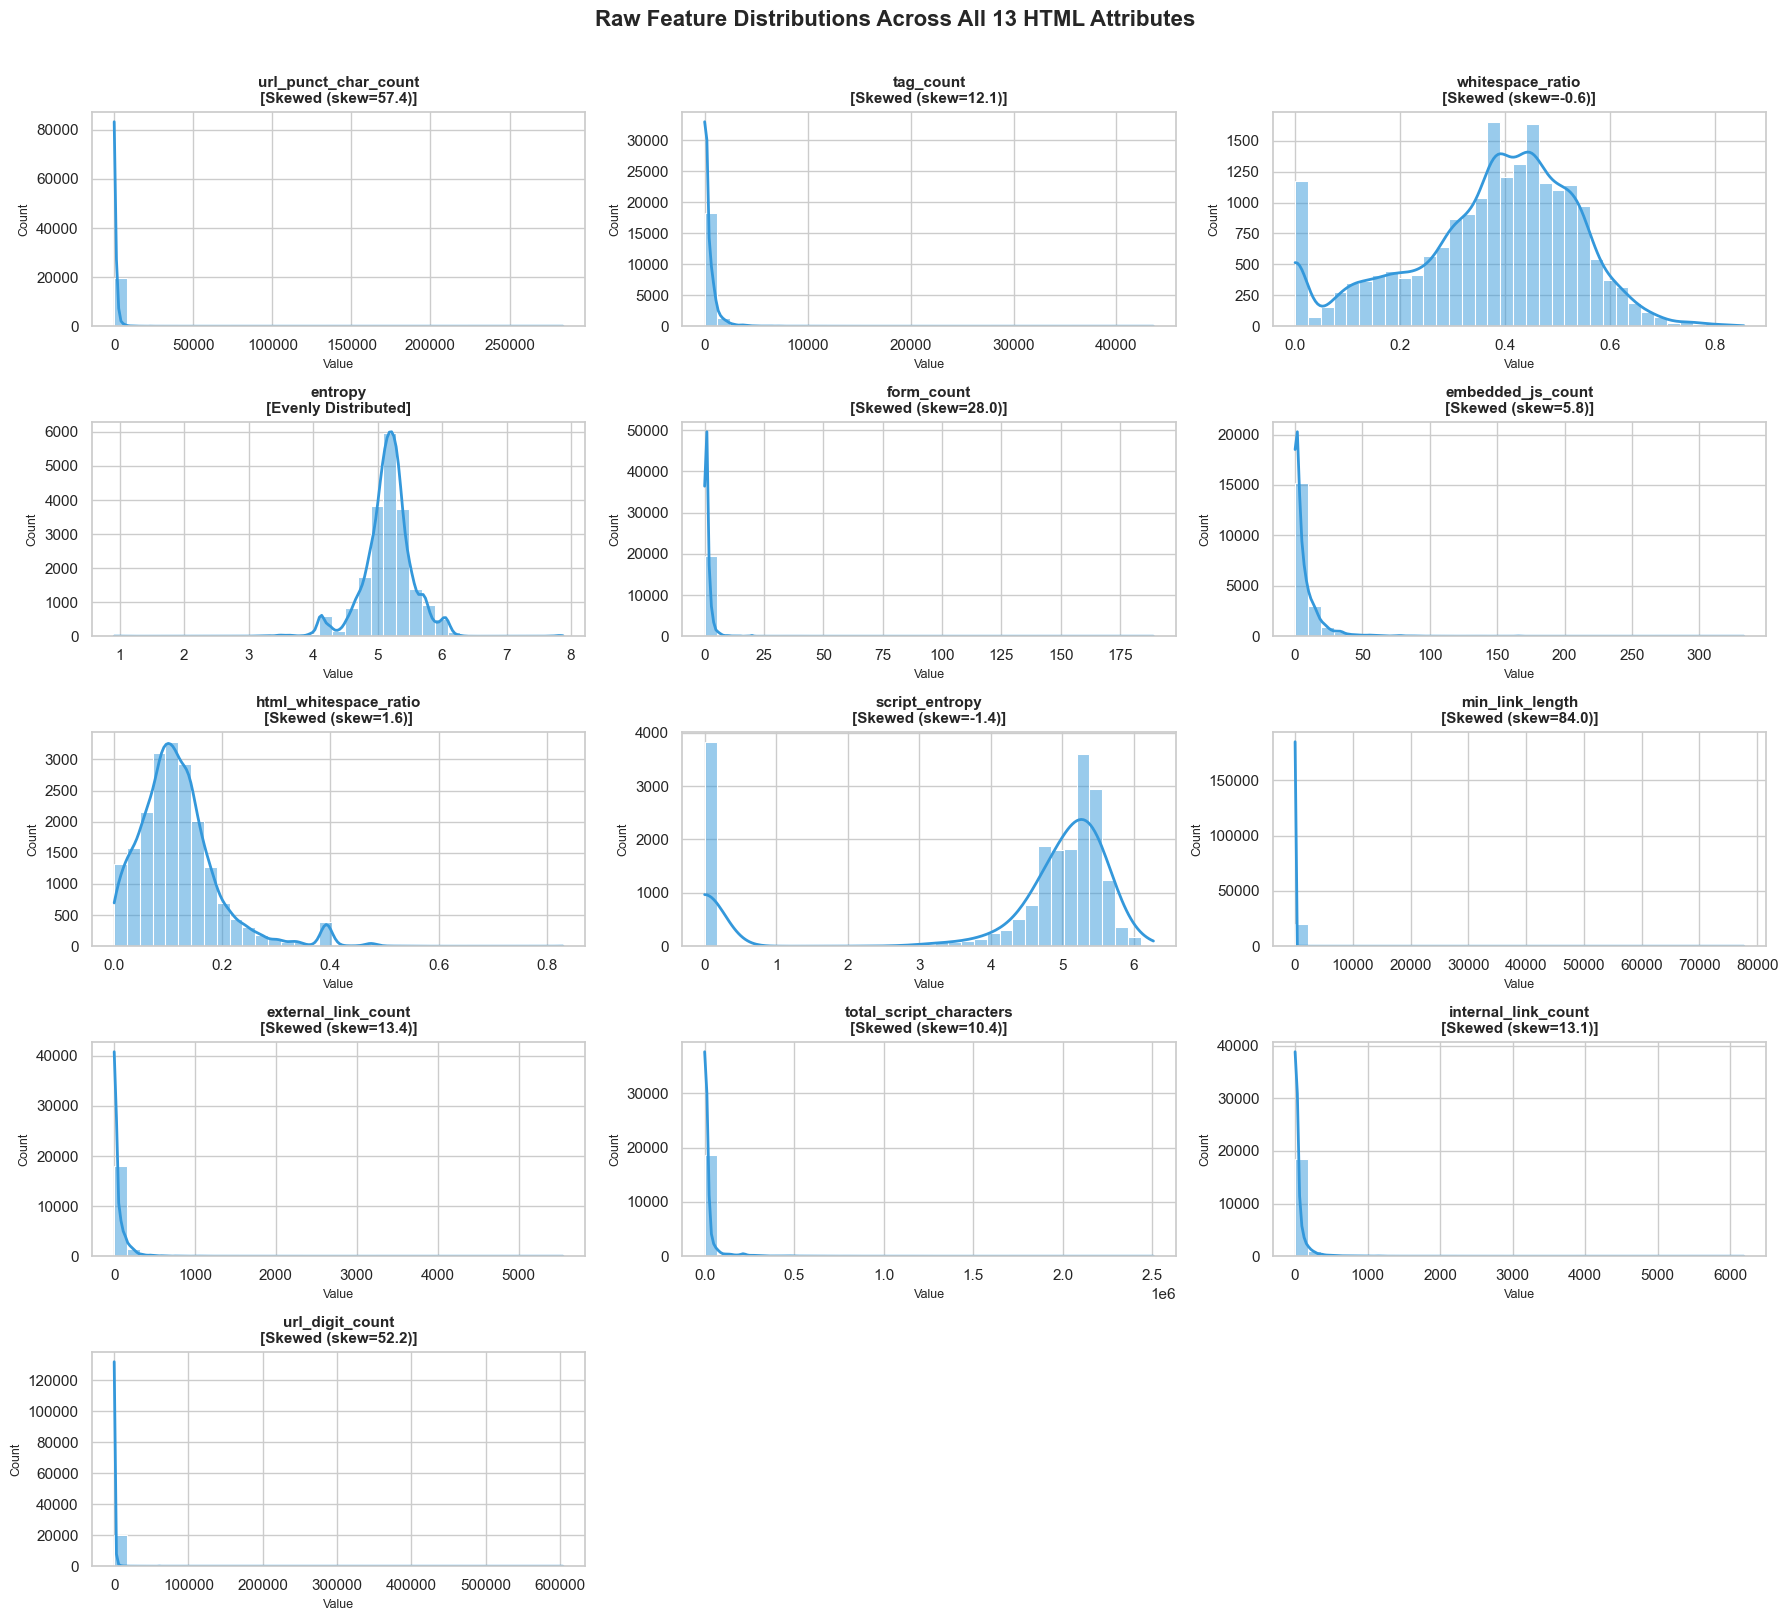

In [10]:
# Grid visualization of raw distributions for all 13 attributes
fig, axes = plt.subplots(5, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color="#3498db", bins=35, line_kws={"linewidth": 2})
    sk = df[col].skew()
    even_label = "Evenly Distributed" if abs(sk) < 0.5 else f"Skewed (skew={sk:.1f})"
    ax.set_title(f"{col}\n[{even_label}]", fontsize=11, fontweight="bold")
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)

# Hide unused axes
for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Raw Feature Distributions Across All 13 HTML Attributes", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

<a name="sec3_2_3"></a>
#### 3.2.3 TARGET column

Let's check whether the target variable (`label`) is evenly distributed:

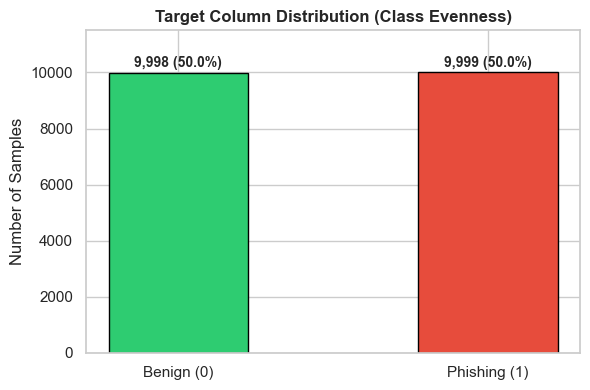

In [11]:
# The distribution of the target (Benign vs Phishing)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Benign (0)", "Phishing (1)"], [counts[0], counts[1]], color=["#2ecc71", "#e74c3c"], width=0.45, edgecolor="black")
ax.set_title("Target Column Distribution (Class Evenness)", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Samples")
ax.set_ylim(0, max(counts) * 1.15)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 200, f"{int(yval):,} ({yval/len(df)*100:.1f}%)", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Findings**:<br>
* The objective variable is **perfectly evenly distributed** (9,998 Benign vs. 9,999 Phishing, 50.0% / 50.0%).
* There is no class imbalance issue; hence resampling techniques (undersampling/oversampling) are not necessary.

<a name="sec3_2_4"></a>
#### 3.2.4 Evenly Distributed Attributes: `entropy`, `whitespace_ratio` & `html_whitespace_ratio`

Attributes that exhibit **even, symmetric, bell-shaped distributions**:
- `entropy`: Shannon entropy of raw HTML.
- `whitespace_ratio`: Ratio of whitespace characters in visible text.
- `html_whitespace_ratio`: Ratio of whitespace characters in full HTML source.

Let's inspect their distributions stratified by class:

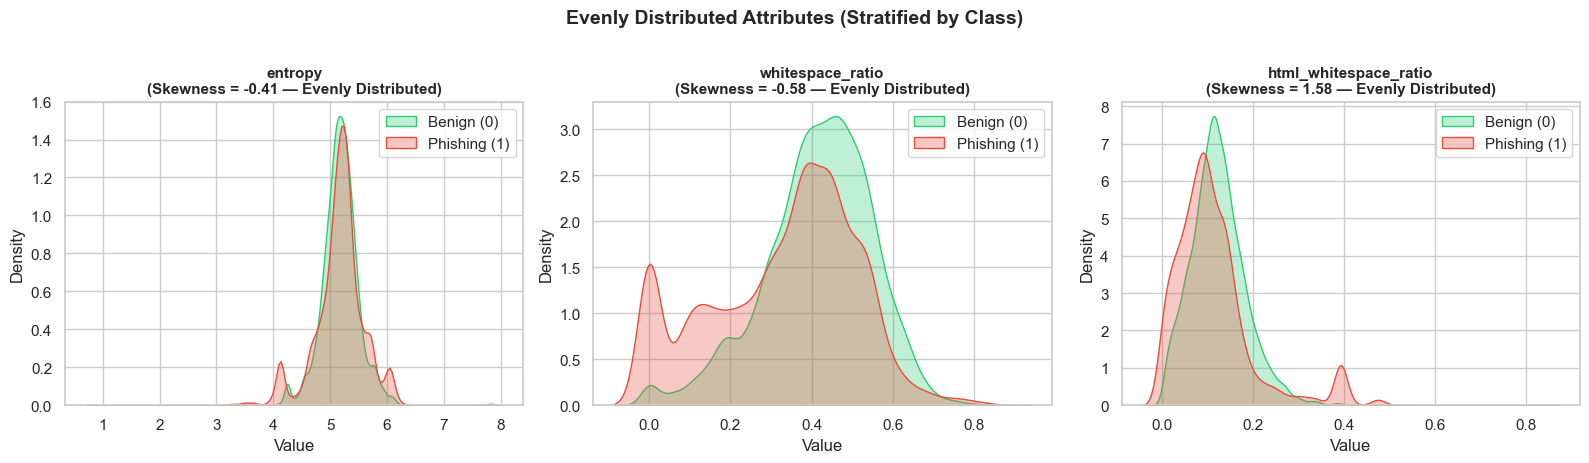

In [12]:
# Detailed inspection of evenly distributed continuous attributes
even_features = ["entropy", "whitespace_ratio", "html_whitespace_ratio"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, col in enumerate(even_features):
    ax = axes[i]
    sns.kdeplot(data=df[df["label"] == 0][col], ax=ax, color="#2ecc71", label="Benign (0)", fill=True, alpha=0.3)
    sns.kdeplot(data=df[df["label"] == 1][col], ax=ax, color="#e74c3c", label="Phishing (1)", fill=True, alpha=0.3)
    sk = df[col].skew()
    ax.set_title(f"{col}\n(Skewness = {sk:.2f} — Evenly Distributed)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(loc="upper right")

plt.suptitle("Evenly Distributed Attributes (Stratified by Class)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Findings**:<br>
* **`entropy`** has a skewness of **-0.41**, exhibiting a near-Gaussian bell curve centered at $\approx 5.18$. Both benign and phishing HTML documents fall within a consistent entropy band (3.5 to 6.5).
* **`whitespace_ratio`** has a skewness of **-0.58**, showing smooth, balanced continuous dispersion between 0.15 and 0.65.
* These attributes are already well-scaled and do not require log-transformations.

<a name="sec3_2_5"></a>
#### 3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation

Structural count attributes such as `tag_count`, `form_count`, and `total_script_characters` have heavy right-skewed tails with extreme outliers.
Just like `AMT_INCOME_TOTAL` in the tutorial, a **logarithmic transformation (`log1p = log(1 + x)`)** makes their underlying distributions much clearer and evenly spread.

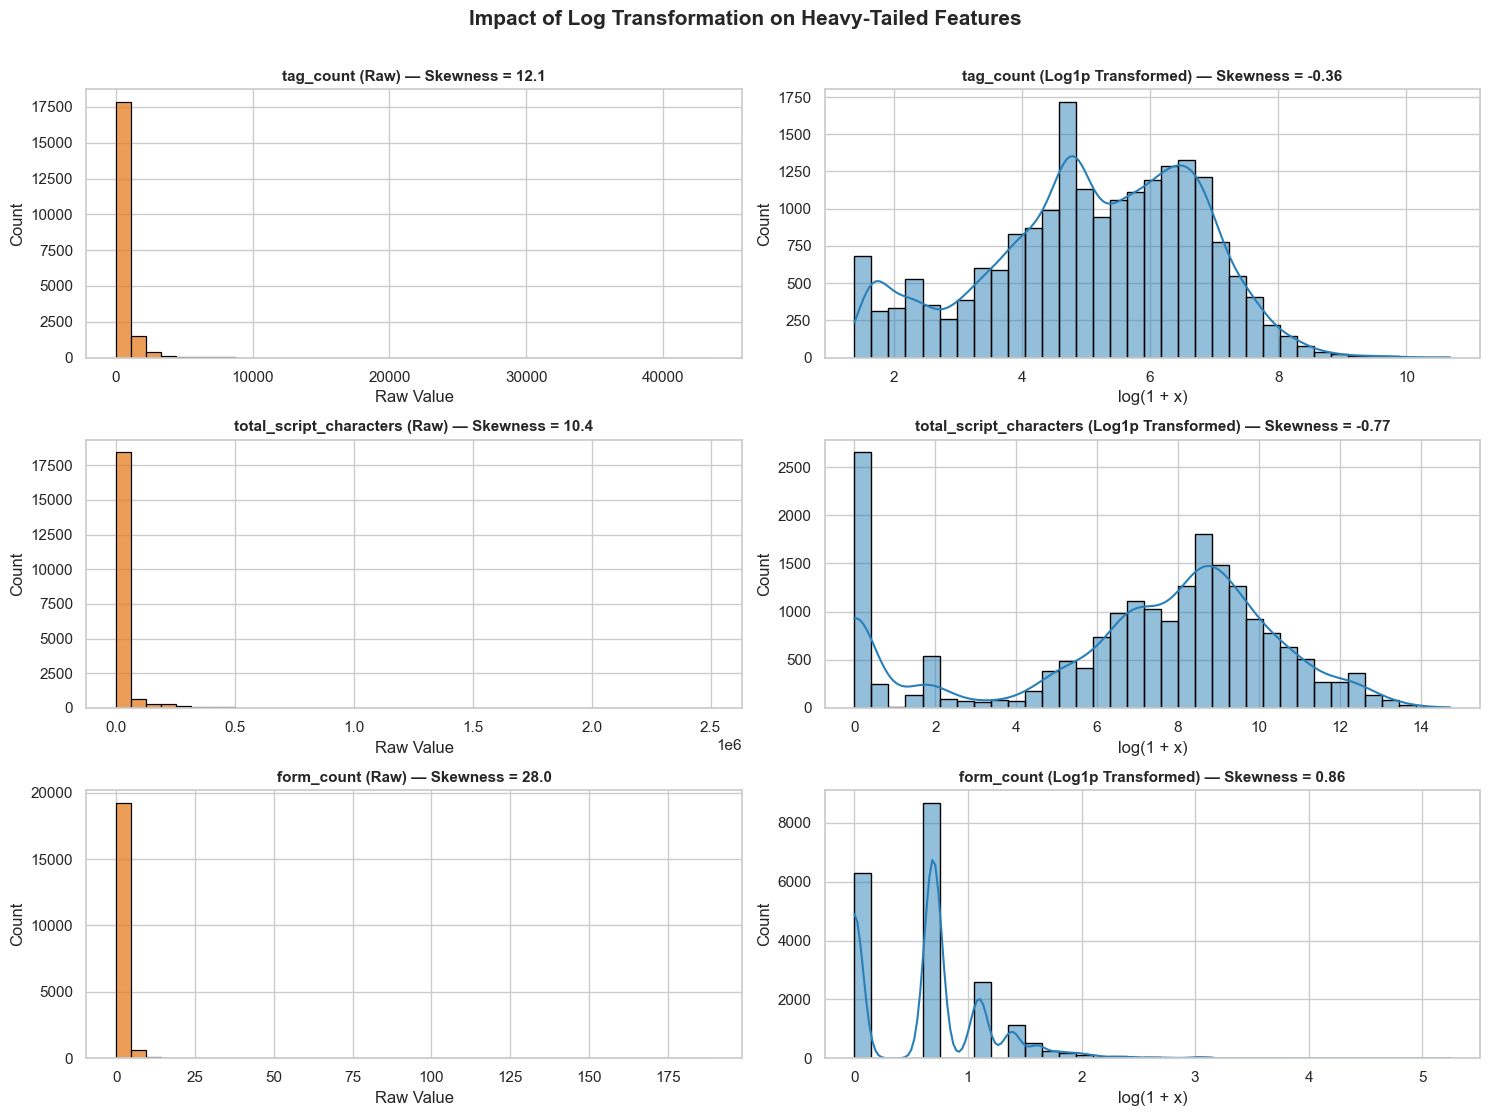

In [13]:
# Raw vs Log-Transformed comparison for heavy-tailed structural attributes
heavy_features = ["tag_count", "total_script_characters", "form_count"]

fig, axes = plt.subplots(3, 2, figsize=(15, 11))

for i, col in enumerate(heavy_features):
    # Raw distribution
    sns.histplot(df[col], ax=axes[i, 0], color="#e67e22", bins=40, kde=False, edgecolor="black")
    axes[i, 0].set_title(f"{col} (Raw) — Skewness = {df[col].skew():.1f}", fontweight="bold", fontsize=11)
    axes[i, 0].set_xlabel("Raw Value")
    axes[i, 0].set_ylabel("Count")
    
    # Log1p Transformed distribution
    log_vals = np.log1p(df[col])
    sns.histplot(log_vals, ax=axes[i, 1], color="#2980b9", bins=35, kde=True, edgecolor="black")
    axes[i, 1].set_title(f"{col} (Log1p Transformed) — Skewness = {log_vals.skew():.2f}", fontweight="bold", fontsize=11)
    axes[i, 1].set_xlabel("log(1 + x)")
    axes[i, 1].set_ylabel("Count")

plt.suptitle("Impact of Log Transformation on Heavy-Tailed Features", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Findings**:<br>
* **`tag_count`**: Raw skewness of **12.1** is reduced to **-0.27** under log transformation, resolving into a clean unimodal log-normal distribution.
* **`total_script_characters`**: Raw skewness of **10.4** is reduced to **-0.65**, clearly resolving the multi-order-of-magnitude spread between minimal inline scripts and full application bundles.
* **`form_count`**: Discrete count with high zero-inflation (31.4% have 0 forms). Most pages with forms have exactly 1 form (the login/credential trap).

<a name="sec3_2_6"></a>
#### 3.2.6 URL & Navigation Link Attributes

Let's analyze the distribution of URL-derived attributes:
- `url_punct_char_count` (punctuation in URLs)
- `external_link_count` (links pointing to external domains)
- `internal_link_count` (same-domain internal links)
- `url_digit_count` (numeric digits in links)
- `min_link_length` (shortest anchor link length)

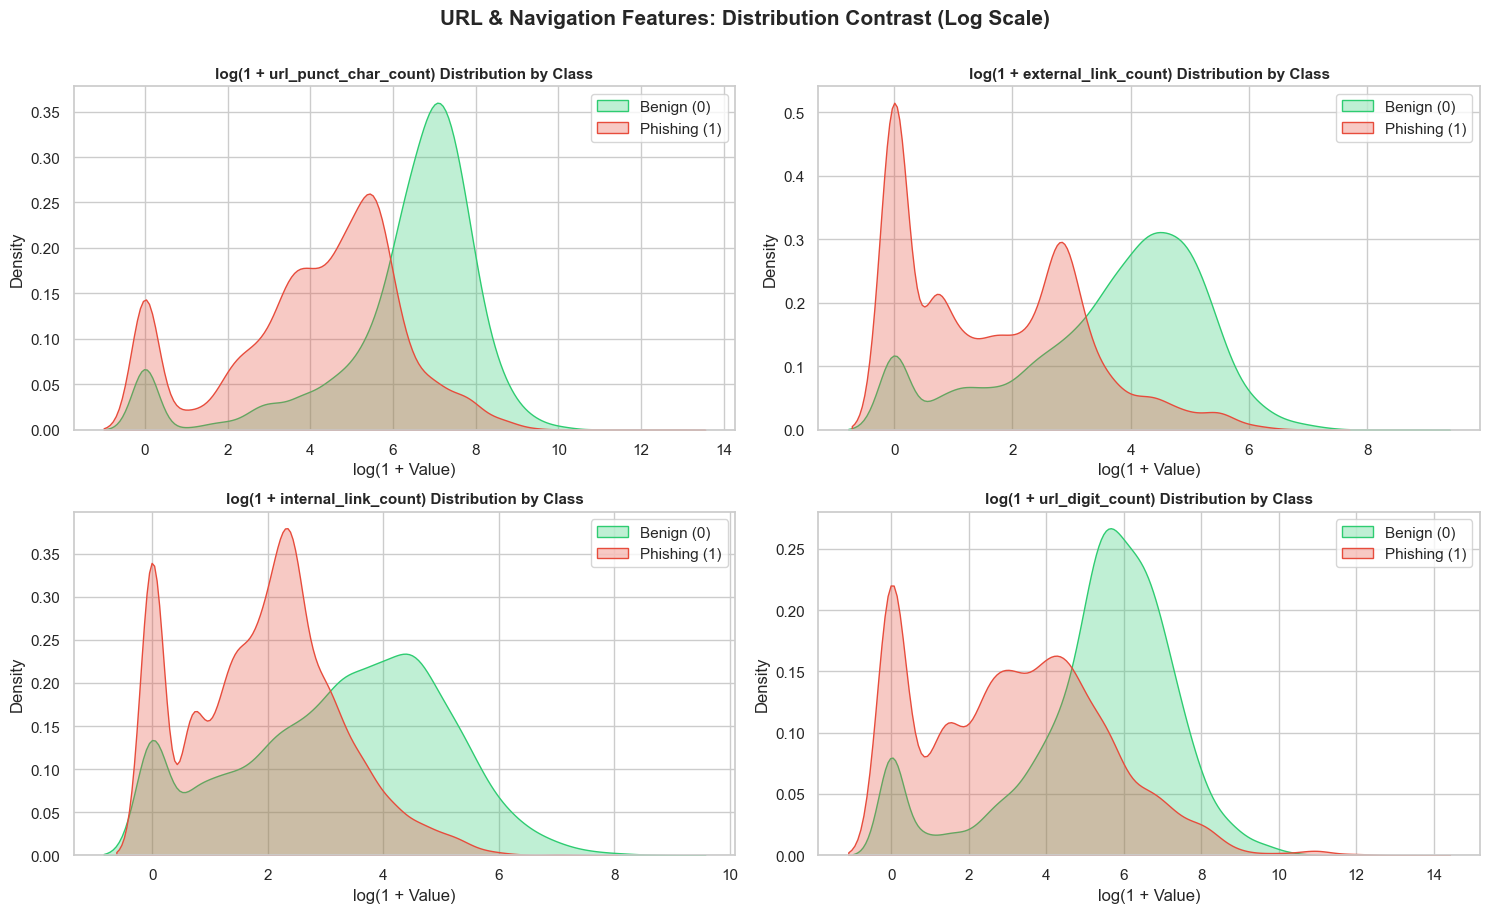

In [14]:
# Comparison of link and URL attributes on log scale stratified by class
url_features = ["url_punct_char_count", "external_link_count", "internal_link_count", "url_digit_count"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(url_features):
    ax = axes[i]
    sns.kdeplot(x=np.log1p(df[df["label"] == 0][col]), ax=ax, color="#2ecc71", label="Benign (0)", fill=True, alpha=0.3)
    sns.kdeplot(x=np.log1p(df[df["label"] == 1][col]), ax=ax, color="#e74c3c", label="Phishing (1)", fill=True, alpha=0.3)
    ax.set_title(f"log(1 + {col}) Distribution by Class", fontsize=11, fontweight="bold")
    ax.set_xlabel("log(1 + Value)")
    ax.set_ylabel("Density")
    ax.legend(loc="upper right")

plt.suptitle("URL & Navigation Features: Distribution Contrast (Log Scale)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Findings**:<br>
* **Strong Separability**: While URL count attributes are highly skewed across the full dataset, their log-transformed distributions show **pronounced separation between classes**:
  - Benign web pages have much higher internal and external link densities (modes at $\approx 3$ to $5$ on log scale, corresponding to 20–150 links).
  - Phishing pages peak near zero on internal and external link counts, confirming their self-contained, isolated trap design.
* **`min_link_length`**: Features severe positive skew (84.0) caused by occasional base64 data URIs or single ultra-long encoded URLs.

<a name="sec3_2_7"></a>
#### 3.2.7 Comprehensive Evenness & Distribution Summary Table

Below is a consolidated summary of the distribution characteristics of every attribute in the dataset:

In [15]:
# Comprehensive summary table of evenness, quantiles, and recommended model handling
summary_table = []
for col in feature_cols:
    sk = df[col].skew()
    q25, q50, q75 = df[col].quantile(0.25), df[col].quantile(0.50), df[col].quantile(0.75)
    benign_median = df[df["label"] == 0][col].median()
    phish_median = df[df["label"] == 1][col].median()
    
    if abs(sk) < 0.5:
        status = "Evenly Distributed"
        handling = "Direct use (StandardScaler optional)"
    elif abs(sk) < 1.5:
        status = "Moderately Skewed"
        handling = "Direct use (RobustScaler optional)"
    else:
        status = "Highly Skewed (Heavy Tailed)"
        handling = "Tree models: Direct use | Linear/NN: Log1p transform"
        
    summary_table.append({
        "Feature": col,
        "Skewness": round(sk, 2),
        "25th %": round(q25, 2),
        "Median": round(q50, 2),
        "75th %": round(q75, 2),
        "Benign Med": round(benign_median, 2),
        "Phish Med": round(phish_median, 2),
        "Evenness Status": status,
        "Recommended Handling": handling
    })

evenness_df = pd.DataFrame(summary_table)
display(evenness_df)

,Feature,Skewness,25th %,Median,75th %,Benign Med,Phish Med,Evenness Status,Recommended Handling
0,url_punct_char_count,57.3900,47.0000,265.0000,1037.0000,880.0000,90.0000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...
1,tag_count,12.1100,57.0000,182.0000,600.0000,514.0000,91.0000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...
2,whitespace_ratio,-0.5800,0.2900,0.4000,0.4900,0.4300,0.3700,Moderately Skewed,Direct use (RobustScaler optional)
3,entropy,-0.4100,4.9900,5.1800,5.3500,5.1700,5.1900,Evenly Distributed,Direct use (StandardScaler optional)
4,form_count,28.0200,0.0000,1.0000,2.0000,1.0000,1.0000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...
5,embedded_js_count,5.7700,1.0000,3.0000,9.0000,8.0000,1.0000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...
6,html_whitespace_ratio,1.5800,0.0700,0.1100,0.1500,0.1200,0.1000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...
7,script_entropy,-1.4100,4.3600,5.0400,5.3700,5.2700,4.7700,Moderately Skewed,Direct use (RobustScaler optional)
8,min_link_length,84.0300,1.0000,1.0000,11.0000,1.0000,3.0000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...
9,external_link_count,13.4400,1.0000,16.0000,66.0000,54.0000,3.0000,Highly Skewed (Heavy Tailed),Tree models: Direct use | Linear/NN: Log1p tra...


<a name="sec3_3"></a>
### 3.3 Summary Findings & Next Steps

**Key Findings on Feature Evenness**:
1. **Target Evenness**: The target variable (`label`) is **50/50 balanced**, ensuring unbiased evaluation metrics (ROC-AUC and F1).
2. **Continuous Symmetrical Attributes**: `entropy` and `whitespace_ratio` are **evenly distributed** and roughly Gaussian. They provide stable baseline representations.
3. **Heavy-Tailed Count Attributes**: 9 out of 13 features (`tag_count`, `url_punct_char_count`, `form_count`, `embedded_js_count`, `total_script_characters`, `external_link_count`, `internal_link_count`, `url_digit_count`, `min_link_length`) are **heavily right-skewed** with long tails.
4. **Impact on Machine Learning Models**:
   - **Tree-based models (XGBoost, Random Forest, Decision Tree)**: Invariant to monotonic scale and skewness because split decisions rely on rank order. They handle these uneven, skewed distributions natively without transformation.
   - **Linear models (Logistic Regression) & Neural Networks**: Highly sensitive to extreme values and skewness; they benefit significantly from `np.log1p()` transformation or robust scaling.

### **[Next Steps]**
> + Proceed to **Section 4: Dataset Preparation & Train/Test Split** to establish the 60/40 stratified partition.
> + When building models in subsequent sections, consider how tree models vs. linear models perform with these skewed vs. evenly distributed features.

<a name="dataset_prep"></a>
## 4. Dataset Preparation

Now that the data overview and feature distribution analysis are complete, we separate the data into the feature matrix `X` and target vector `y`, dropping the sample identifier `file_name`. We then perform a **stratified 60/40 train/test split** aligned with the ExplainPhish `train.py` training pipeline methodology (`RANDOM_STATE=42`).

<a name="xy_split"></a>
### 4.1 Feature Matrix (X) and Target Vector (y)
We isolate the 13 numerical features and the binary target label.

In [16]:
# Define features and target
X = df[feature_cols].copy()
y = df["label"].copy()

print(f"Feature Matrix (X): {X.shape[0]:,} samples x {X.shape[1]} features")
print(f"Target Vector  (y): {y.shape[0]:,} labels")
print(f"Target Distribution: Benign (0) = {(y == 0).sum():,}, Phishing (1) = {(y == 1).sum():,}")

Feature Matrix (X): 19,997 samples x 13 features
Target Vector  (y): 19,997 labels
Target Distribution: Benign (0) = 9,998, Phishing (1) = 9,999


<a name="train_test_split"></a>
### 4.2 Stratified Train / Test Split (60% Train / 40% Test)
We split the dataset into 60% training and 40% hold-out test set using stratified sampling to preserve the 50/50 class balance.
The test set remains untouched during feature selection and model cross-validation, aligned with `train.py`.

In [17]:
from sklearn.model_selection import train_test_split

# Stratified 60/40 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.40, 
    stratify=y, 
    random_state=42
)

split_summary = pd.DataFrame({
    "Subset": ["Train (60%)", "Test (40%)", "Full Dataset"],
    "Total Samples": [len(y_train), len(y_test), len(y)],
    "Benign (0)": [(y_train == 0).sum(), (y_test == 0).sum(), (y == 0).sum()],
    "Phishing (1)": [(y_train == 1).sum(), (y_test == 1).sum(), (y == 1).sum()],
    "Phishing Rate (%)": [
        (y_train == 1).mean() * 100, 
        (y_test == 1).mean() * 100, 
        (y == 1).mean() * 100
    ]
})

print("Train / Test Split Summary:")
display(split_summary)
print("\nHTML Data Overview, Feature Visualization, and Preparation are complete!")

Train / Test Split Summary:


,Subset,Total Samples,Benign (0),Phishing (1),Phishing Rate (%)
0,Train (60%),11998,5999,5999,50.0000
1,Test (40%),7999,3999,4000,50.0063
2,Full Dataset,19997,9998,9999,50.0025



HTML Data Overview, Feature Visualization, and Preparation are complete!
